##### Online Retail Analytics & Recommendation System 
##### Internship Project — Plasmid Innovation Ltd
##### Dataset: UCI Online Retail Dataset (541,909 transactions)

In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

In [6]:
# Load Dataset 
df = pd.read_excel(r"C:\Users\Dell\Downloads\OnlineRetail (1) (1).xlsx")
 
print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Data:")
df.head()

Shape: (541909, 8)

Column Types:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Sample Data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
# Data Cleaning 
print("Rows BEFORE cleaning:", len(df))
 
# Remove rows with missing Description or CustomerID
df.dropna(inplace=True)
 
# Remove cancelled invoices (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
 
# Keep only valid transactions
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
 
print("Rows AFTER cleaning :", len(df))
print(f"Removed {541909 - len(df):,} invalid rows")
 

Rows BEFORE cleaning: 541909
Rows AFTER cleaning : 397884
Removed 144,025 invalid rows


In [12]:
# Feature Engineering 
# Revenue = Quantity × UnitPrice
df['Revenue'] = df['Quantity'] * df['UnitPrice']
 
# Extract Month and Year for time-based analysis
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['MonthName'] = df['InvoiceDate'].dt.strftime('%B %Y')
 
print("Total Revenue  : £{:,.2f}".format(df['Revenue'].sum()))
print("Unique Customers:", df['CustomerID'].nunique())
print("Unique Products :", df['Description'].nunique())
print("Date Range      :", df['InvoiceDate'].min().date(),
      "→", df['InvoiceDate'].max().date())

Total Revenue  : £8,911,407.90
Unique Customers: 4338
Unique Products : 3866
Date Range      : 2010-12-01 → 2011-12-09


In [14]:
# EDA — Top Products by Quantity 
top_products = (df.groupby('Description')['Quantity']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))
 
print("Top 10 Products by Quantity Sold:")
print(top_products)

Top 10 Products by Quantity Sold:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [16]:
# EDA — Top Products by Revenue 
# Exclude POSTAGE — not a real product
top_revenue_products = (df[df['Description'] != 'POSTAGE']
                          .groupby('Description')['Revenue']
                          .sum()
                          .sort_values(ascending=False)
                          .head(10))
 
print("Top 10 Products by Revenue:")
print(top_revenue_products)

Top 10 Products by Revenue:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
CHILLI LIGHTS                          46286.51
Name: Revenue, dtype: float64


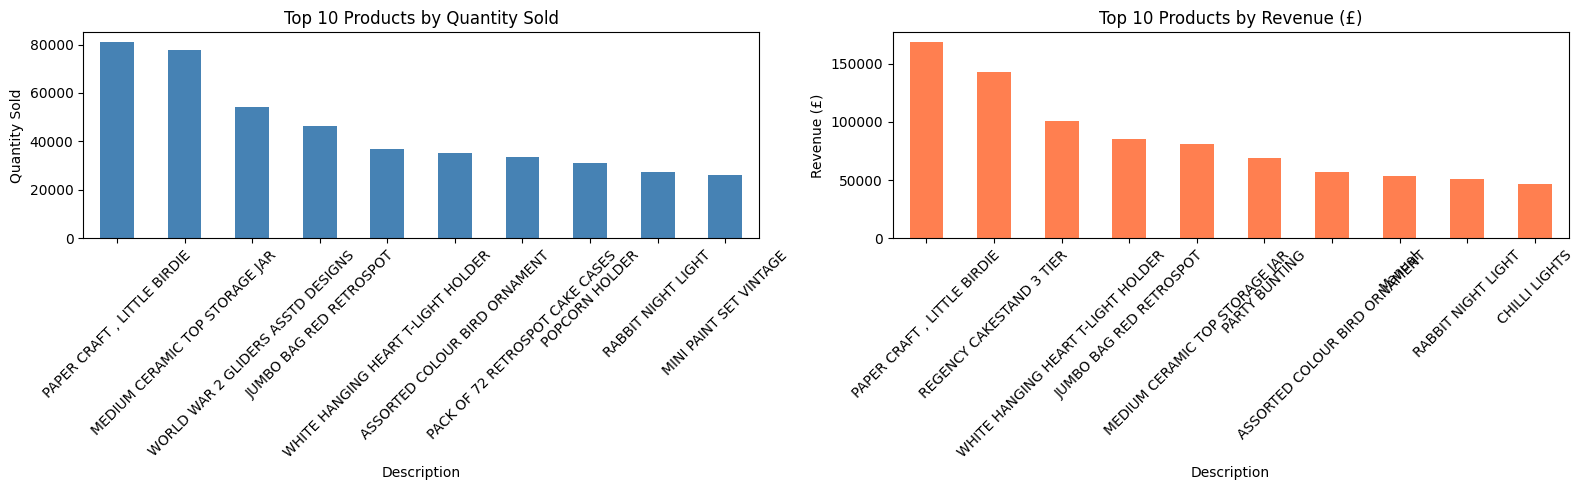

In [18]:
# Chart — Quantity vs Revenue Side by Side 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
top_products.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Top 10 Products by Quantity Sold")
axes[0].set_ylabel("Quantity Sold")
axes[0].tick_params(axis='x', rotation=45)
 
top_revenue_products.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Top 10 Products by Revenue (£)")
axes[1].set_ylabel("Revenue (£)")
axes[1].tick_params(axis='x', rotation=45)
 
plt.tight_layout()
plt.show()

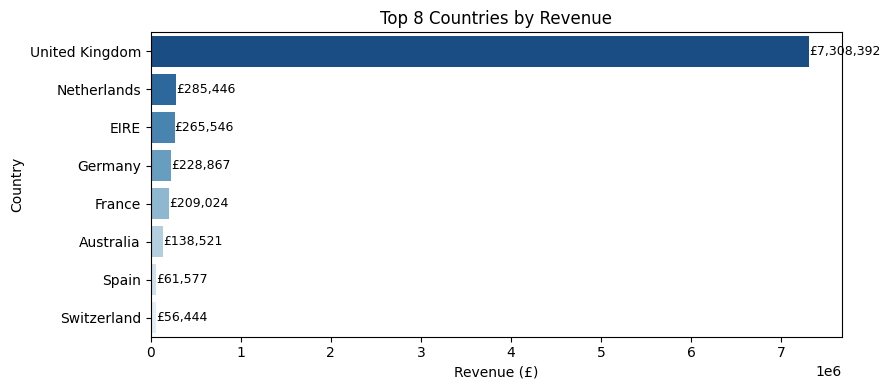

In [20]:
# EDA — Country-wise Revenue 
country_revenue = (df.groupby('Country')['Revenue']
                     .sum()
                     .sort_values(ascending=False)
                     .head(8))
 
plt.figure(figsize=(9, 4))
ax = sns.barplot(x=country_revenue.values, y=country_revenue.index,
                 hue=country_revenue.index, legend=False, palette='Blues_r')
for i, v in enumerate(country_revenue.values):
    ax.text(v + 500, i, f'£{v:,.0f}', va='center', fontsize=9)
plt.title("Top 8 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

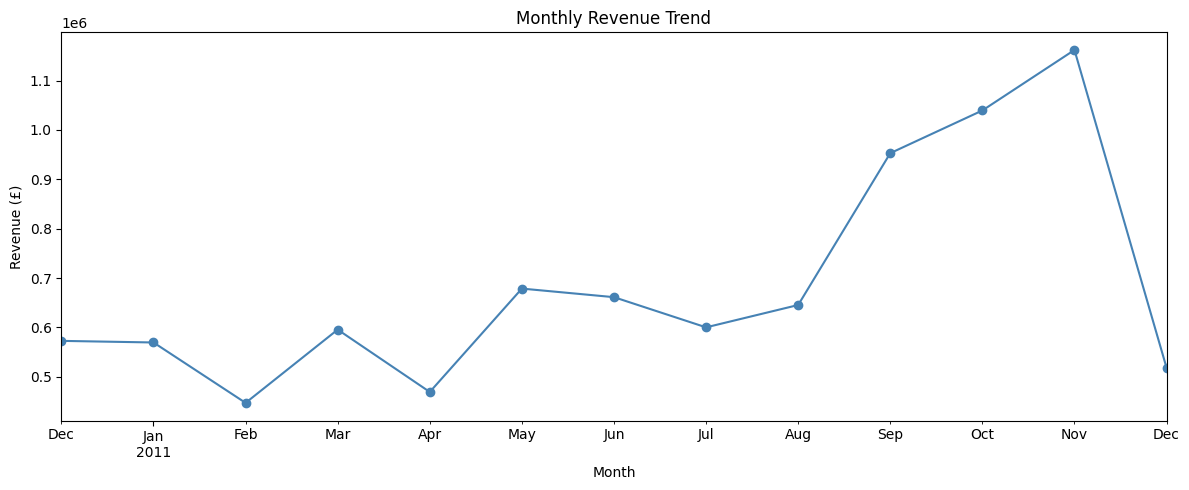

Peak revenue month: 2011-11 — £1,161,817.38


In [22]:
# EDA — Monthly Revenue Trend 
monthly_sales = df.groupby('Month')['Revenue'].sum()
 
monthly_sales.plot(figsize=(12, 5), marker='o', color='steelblue')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()
 
peak_month = monthly_sales.idxmax()
print(f"Peak revenue month: {peak_month} — £{monthly_sales.max():,.2f}")


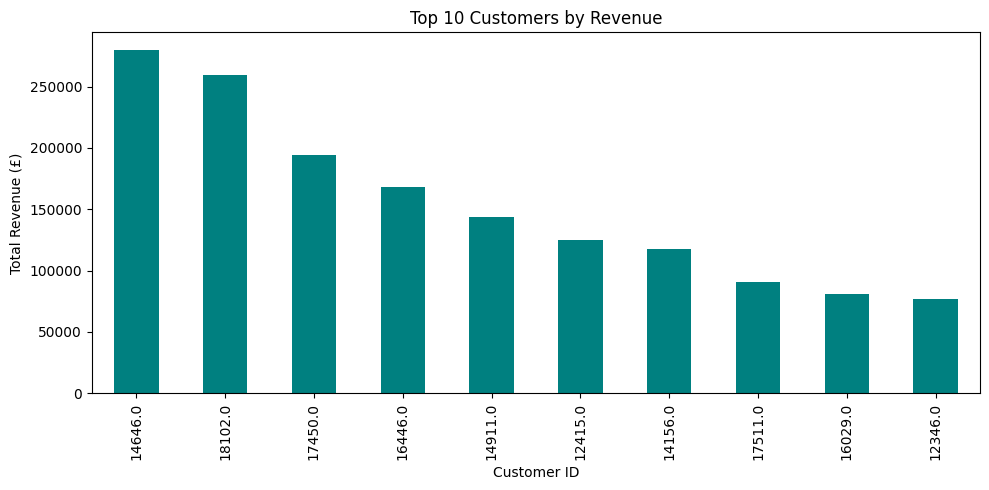

In [24]:
# EDA — Top Customers by Spending 
customer_spending = (df.groupby('CustomerID')['Revenue']
                       .sum()
                       .sort_values(ascending=False))
 
customer_spending.head(10).plot(kind='bar', figsize=(10, 5), color='teal')
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Total Revenue (£)")
plt.xlabel("Customer ID")
plt.tight_layout()
plt.show()

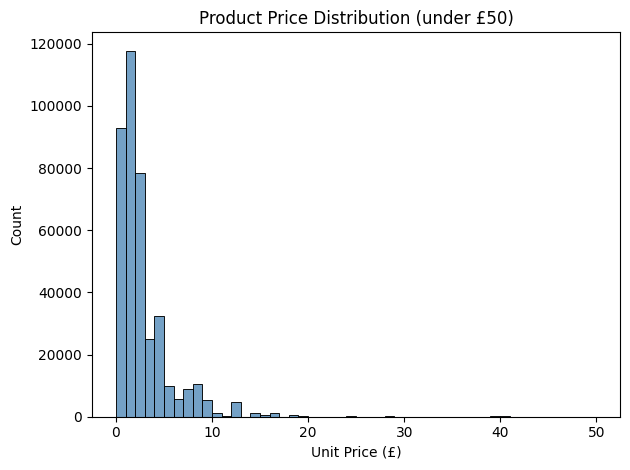

Note: 376 items above £50 excluded from chart


In [26]:
# EDA — Product Price Distribution 
price_filtered = df[df['UnitPrice'] < 50]
sns.histplot(price_filtered['UnitPrice'], bins=50, color='steelblue')
plt.title("Product Price Distribution (under £50)")
plt.xlabel("Unit Price (£)")
plt.tight_layout()
plt.show()
print(f"Note: {len(df[df['UnitPrice'] >= 50]):,} items above £50 excluded from chart")

Basket Size Summary:
count    18532.00
mean       278.86
std        972.72
min          1.00
25%         74.00
50%        155.00
75%        291.00
max      80995.00
Name: Quantity, dtype: float64


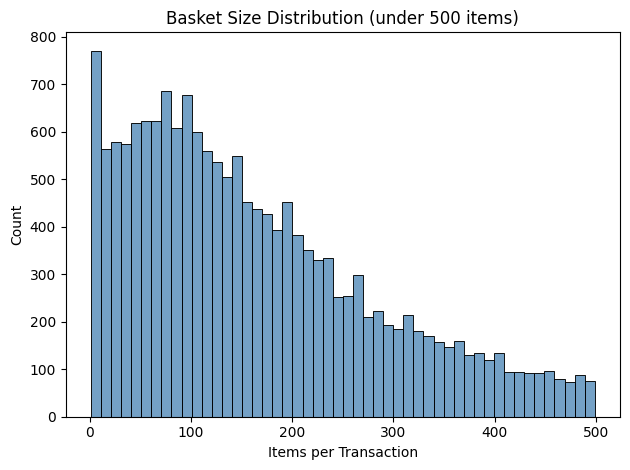

In [28]:
# EDA — Basket Size Analysis 
basket_size = df.groupby('InvoiceNo')['Quantity'].sum()
 
print("Basket Size Summary:")
print(basket_size.describe().round(2))
 
sns.histplot(basket_size[basket_size < 500], bins=50, color='steelblue')
plt.title("Basket Size Distribution (under 500 items)")
plt.xlabel("Items per Transaction")
plt.tight_layout()
plt.show()

In [30]:
# Business Insights Summary 
total_revenue = df['Revenue'].sum()
total_customers = df['CustomerID'].nunique()
total_orders = df['InvoiceNo'].nunique()
top_country = df.groupby('Country')['Revenue'].sum().idxmax()
top_product = df.groupby('Description')['Quantity'].sum().idxmax()
top10_rev = customer_spending.head(10).sum()
 
print("=" * 55)
print("  KEY BUSINESS INSIGHTS")
print("=" * 55)
print(f"  Total Revenue        : £{total_revenue:,.2f}")
print(f"  Unique Customers     : {total_customers:,}")
print(f"  Total Orders         : {total_orders:,}")
print(f"  Countries            : {df['Country'].nunique()}")
print(f"  Top Country          : {top_country}")
print(f"  Top Product (qty)    : {top_product}")
print(f"  Top 10 customers     : £{top10_rev:,.2f} "
      f"({top10_rev/total_revenue*100:.1f}% of revenue)")
print("=" * 55)

  KEY BUSINESS INSIGHTS
  Total Revenue        : £8,911,407.90
  Unique Customers     : 4,338
  Total Orders         : 18,532
  Countries            : 37
  Top Country          : United Kingdom
  Top Product (qty)    : PAPER CRAFT , LITTLE BIRDIE
  Top 10 customers     : £1,538,276.65 (17.3% of revenue)


In [32]:
# Build Product Pairs (co-occurrence) 
basket = df.groupby('InvoiceNo')['Description'].apply(list)
 
pair_counter = Counter()
for items in basket:
    unique_items = set(items)
    pairs = combinations(unique_items, 2)
    pair_counter.update(pairs)
 
print(f"Total unique invoices  : {len(basket):,}")
print(f"Total unique item pairs: {len(pair_counter):,}")

Total unique invoices  : 18,532
Total unique item pairs: 2,789,012


In [34]:
# Top 10 Most Co-purchased Pairs 
recommendations = pd.DataFrame(
    pair_counter.most_common(10),
    columns=['Product Pair', 'Co-purchase Frequency']
)
print("Top 10 Most Frequently Bought Together:")
print(recommendations.to_string(index=False))

Top 10 Most Frequently Bought Together:
                                                         Product Pair  Co-purchase Frequency
                   (JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT)                    545
   (GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER)                    539
                   (LUNCH BAG  BLACK SKULL., LUNCH BAG RED RETROSPOT)                    510
(GARDENERS KNEELING PAD KEEP CALM, GARDENERS KNEELING PAD CUP OF TEA)                    463
               (ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE RED)                    456
    (GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER)                    449
                   (LUNCH BAG PINK POLKADOT, LUNCH BAG RED RETROSPOT)                    448
                    (JUMBO STORAGE BAG SUKI, JUMBO BAG RED RETROSPOT)                    434
    (PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER)                    433
                       (LUNCH 

### RECOMMENDATION SYSTEM — 3 Types as per project brief

In [36]:
# TYPE 1 — Global Recommendation 
def recommend_global(product_name, top_n=5):
    """
    Recommends products frequently bought together with
    the given product — across all countries and all time.
    """
    related = []
    for (item1, item2), freq in pair_counter.items():
        if item1 == product_name:
            related.append((item2, freq))
        elif item2 == product_name:
            related.append((item1, freq))
 
    related.sort(key=lambda x: x[1], reverse=True)
    result = related[:top_n]
 
    print(f"\n GLOBAL recommendations for: '{product_name}'")
    print("-" * 55)
    for i, (product, freq) in enumerate(result, 1):
        print(f"  {i}. {product}  (bought together {freq} times)")
    return result
 
 
# Test it
recommend_global("WHITE HANGING HEART T-LIGHT HOLDER")


 GLOBAL recommendations for: 'WHITE HANGING HEART T-LIGHT HOLDER'
-------------------------------------------------------
  1. RED HANGING HEART T-LIGHT HOLDER  (bought together 364 times)
  2. HEART OF WICKER SMALL  (bought together 263 times)
  3. WOODEN PICTURE FRAME WHITE FINISH  (bought together 252 times)
  4. CANDLEHOLDER PINK HANGING HEART  (bought together 246 times)
  5. WOODEN FRAME ANTIQUE WHITE  (bought together 229 times)


[('RED HANGING HEART T-LIGHT HOLDER', 364),
 ('HEART OF WICKER SMALL', 263),
 ('WOODEN PICTURE FRAME WHITE FINISH', 252),
 ('CANDLEHOLDER PINK HANGING HEART', 246),
 ('WOODEN FRAME ANTIQUE WHITE', 229)]


 COUNTRY-WISE recommendations for: 'United Kingdom'
-------------------------------------------------------
  1. PAPER CRAFT , LITTLE BIRDIE  (80,995 units sold)
  2. MEDIUM CERAMIC TOP STORAGE JAR  (76,919 units sold)
  3. WORLD WAR 2 GLIDERS ASSTD DESIGNS  (49,182 units sold)
  4. JUMBO BAG RED RETROSPOT  (41,981 units sold)
  5. WHITE HANGING HEART T-LIGHT HOLDER  (34,648 units sold)
  6. ASSORTED COLOUR BIRD ORNAMENT  (32,727 units sold)
  7. POPCORN HOLDER  (28,935 units sold)
  8. PACK OF 12 LONDON TISSUES  (24,337 units sold)
  9. BROCADE RING PURSE  (22,711 units sold)
  10. PACK OF 72 RETROSPOT CAKE CASES  (22,465 units sold)


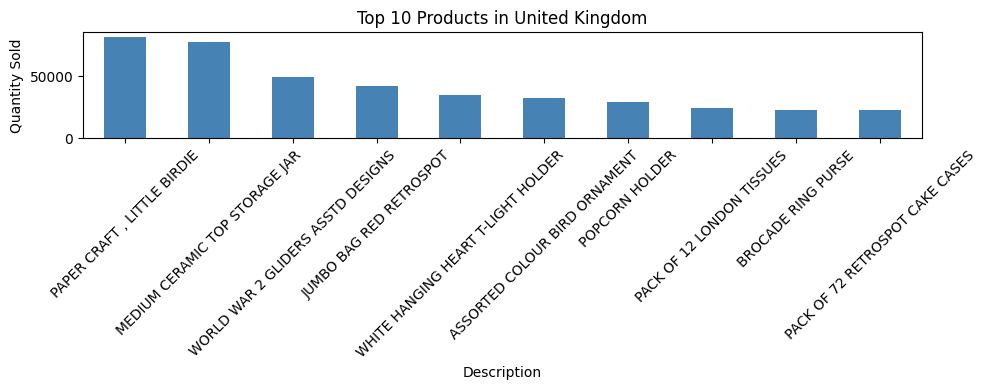


 COUNTRY-WISE recommendations for: 'Germany'
-------------------------------------------------------
  1. ROUND SNACK BOXES SET OF4 WOODLAND  (1,233 units sold)
  2. ASSORTED COLOURS SILK FAN  (1,164 units sold)
  3. POSTAGE  (1,114 units sold)
  4. WOODLAND CHARLOTTE BAG  (1,020 units sold)
  5. PACK OF 72 RETROSPOT CAKE CASES  (1,002 units sold)
  6. PACK OF 6 BIRDY GIFT TAGS  (936 units sold)
  7. SPACEBOY LUNCH BOX  (876 units sold)
  8. PLASTERS IN TIN WOODLAND ANIMALS  (857 units sold)
  9. JAM MAKING SET PRINTED  (816 units sold)
  10. REGENCY CAKESTAND 3 TIER  (809 units sold)


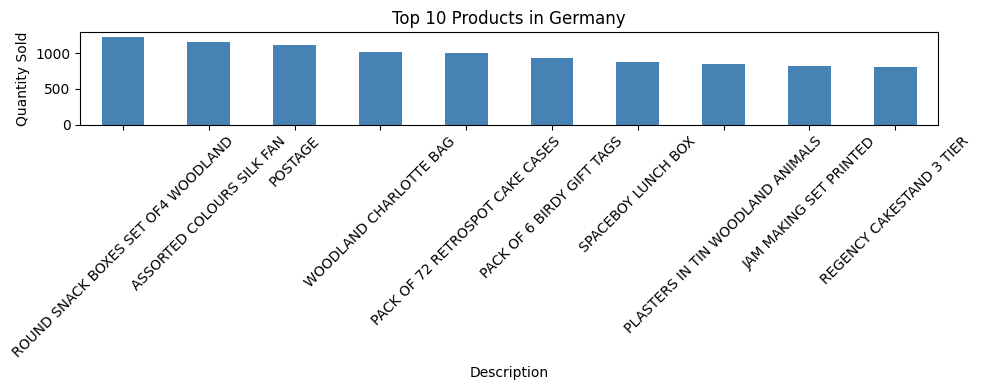


 COUNTRY-WISE recommendations for: 'France'
-------------------------------------------------------
  1. RABBIT NIGHT LIGHT  (4,000 units sold)
  2. MINI PAINT SET VINTAGE  (2,196 units sold)
  3. RED TOADSTOOL LED NIGHT LIGHT  (1,291 units sold)
  4. SET/6 RED SPOTTY PAPER CUPS  (1,272 units sold)
  5. ASSORTED COLOUR BIRD ORNAMENT  (1,204 units sold)
  6. PACK OF 72 RETROSPOT CAKE CASES  (1,176 units sold)
  7. PLASTERS IN TIN CIRCUS PARADE  (1,144 units sold)
  8. PLASTERS IN TIN WOODLAND ANIMALS  (1,144 units sold)
  9. SET/6 RED SPOTTY PAPER PLATES  (1,116 units sold)
  10. PLASTERS IN TIN SPACEBOY  (1,012 units sold)


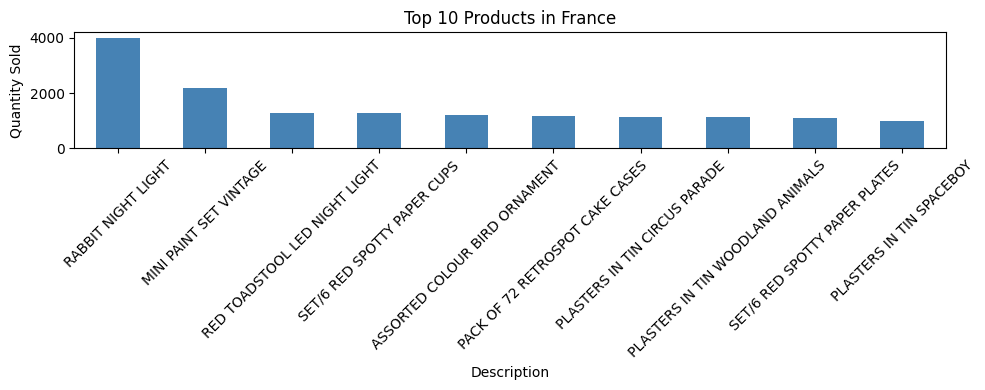

Description
RABBIT NIGHT LIGHT                  4000
MINI PAINT SET VINTAGE              2196
RED TOADSTOOL LED NIGHT LIGHT       1291
SET/6 RED SPOTTY PAPER CUPS         1272
ASSORTED COLOUR BIRD ORNAMENT       1204
PACK OF 72 RETROSPOT CAKE CASES     1176
PLASTERS IN TIN CIRCUS PARADE       1144
PLASTERS IN TIN WOODLAND ANIMALS    1144
SET/6 RED SPOTTY PAPER PLATES       1116
PLASTERS IN TIN SPACEBOY            1012
Name: Quantity, dtype: int64

In [47]:
# TYPE 2 — Country-wise Recommendation 
def recommend_by_country(country_name, top_n=10):
    """
    Recommends the most popular products in a specific country
    based on total quantity sold in that country.
    """
    country_df = df[df['Country'].str.upper() == country_name.upper()]
 
    if country_df.empty:
        print(f"No data found for country: {country_name}")
        print("Available countries:", sorted(df['Country'].unique()))
        return
 
    top = (country_df.groupby('Description')['Quantity']
                     .sum()
                     .sort_values(ascending=False)
                     .head(top_n))
 
    print(f"\n COUNTRY-WISE recommendations for: '{country_name}'")
    print("-" * 55)
    for i, (product, qty) in enumerate(top.items(), 1):
        print(f"  {i}. {product}  ({qty:,} units sold)")
 
    # Bar chart
    top.plot(kind='bar', figsize=(10, 4), color='steelblue')
    plt.title(f"Top {top_n} Products in {country_name}")
    plt.ylabel("Quantity Sold")
    plt.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
 
    return top
 
 
# Test with different countries
recommend_by_country("United Kingdom")
recommend_by_country("Germany")
recommend_by_country("France")


 MONTH-WISE recommendations for: 'November 2011'
-------------------------------------------------------
  1. RABBIT NIGHT LIGHT  (12,393 units sold)
  2. POPCORN HOLDER  (8,458 units sold)
  3. PAPER CHAIN KIT 50'S CHRISTMAS  (5,919 units sold)
  4. JUMBO BAG RED RETROSPOT  (5,678 units sold)
  5. ASSORTED COLOUR BIRD ORNAMENT  (5,190 units sold)
  6. WOODEN STAR CHRISTMAS SCANDINAVIAN  (4,981 units sold)
  7. WHITE HANGING HEART T-LIGHT HOLDER  (4,861 units sold)
  8. WOODEN HEART CHRISTMAS SCANDINAVIAN  (4,582 units sold)
  9. WORLD WAR 2 GLIDERS ASSTD DESIGNS  (4,500 units sold)
  10. DISCO BALL CHRISTMAS DECORATION  (4,391 units sold)


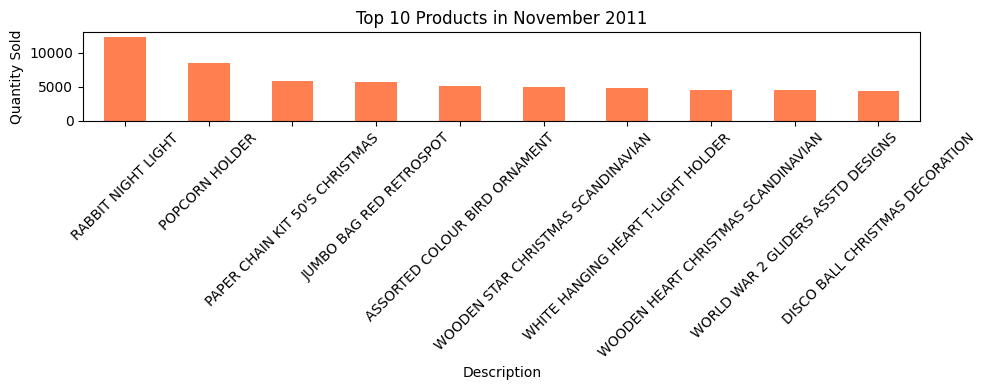


 MONTH-WISE recommendations for: 'December 2011'
-------------------------------------------------------
  1. PAPER CRAFT , LITTLE BIRDIE  (80,995 units sold)
  2. POPCORN HOLDER  (5,362 units sold)
  3. RABBIT NIGHT LIGHT  (3,691 units sold)
  4. VINTAGE DOILY JUMBO BAG RED  (2,086 units sold)
  5. BLACK RECORD COVER FRAME  (1,464 units sold)
  6. METAL SIGN TAKE IT OR LEAVE IT  (1,451 units sold)
  7. DISCO BALL CHRISTMAS DECORATION  (1,446 units sold)
  8. PAPER CHAIN KIT 50'S CHRISTMAS  (1,393 units sold)
  9. WORLD WAR 2 GLIDERS ASSTD DESIGNS  (1,363 units sold)
  10. ASSORTED COLOUR BIRD ORNAMENT  (1,274 units sold)


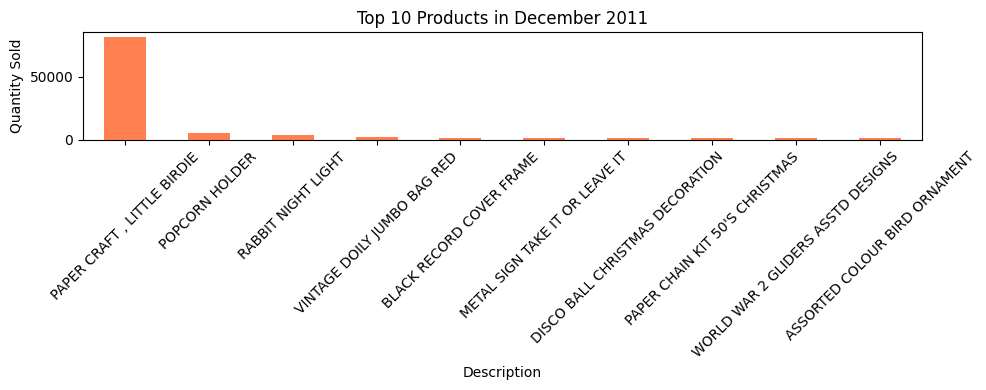


 MONTH-WISE recommendations for: 'December 2010'
-------------------------------------------------------
  1. WORLD WAR 2 GLIDERS ASSTD DESIGNS  (5,139 units sold)
  2. WHITE HANGING HEART T-LIGHT HOLDER  (3,611 units sold)
  3. PACK OF 72 RETROSPOT CAKE CASES  (3,572 units sold)
  4. HAND WARMER BABUSHKA DESIGN  (3,367 units sold)
  5. MINI PAINT SET VINTAGE  (2,700 units sold)
  6. PACK OF 12 LONDON TISSUES  (2,656 units sold)
  7. GROW A FLYTRAP OR SUNFLOWER IN TIN  (2,616 units sold)
  8. ASSORTED COLOUR BIRD ORNAMENT  (2,267 units sold)
  9. CREAM HEART CARD HOLDER  (2,254 units sold)
  10. RED  HARMONICA IN BOX  (2,162 units sold)


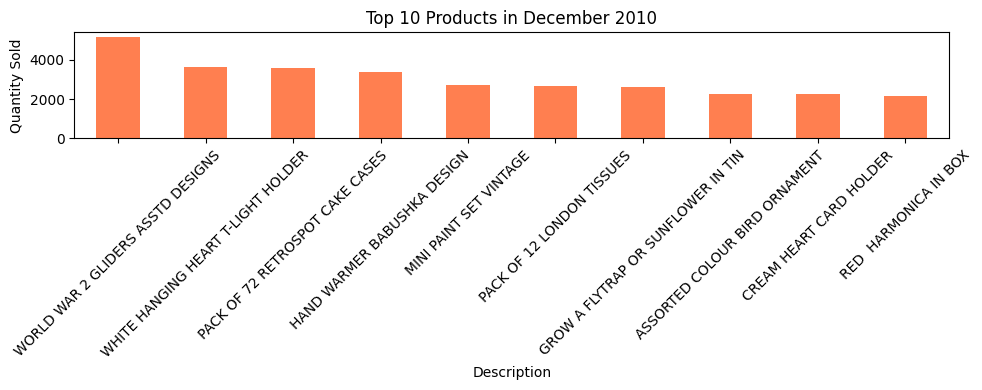

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     5139
WHITE HANGING HEART T-LIGHT HOLDER    3611
PACK OF 72 RETROSPOT CAKE CASES       3572
HAND WARMER BABUSHKA DESIGN           3367
MINI PAINT SET VINTAGE                2700
PACK OF 12 LONDON TISSUES             2656
GROW A FLYTRAP OR SUNFLOWER IN TIN    2616
ASSORTED COLOUR BIRD ORNAMENT         2267
CREAM HEART CARD HOLDER               2254
RED  HARMONICA IN BOX                 2162
Name: Quantity, dtype: int64

In [49]:
# TYPE 3 — Month-wise Recommendation 
def recommend_by_month(month_str, top_n=10):
    """
    Recommends the most popular products in a specific month.
    Format: 'YYYY-MM' e.g. '2011-11' for November 2011
    """
    month_df = df[df['Month'].astype(str) == month_str]
 
    if month_df.empty:
        print(f"No data found for month: {month_str}")
        available = sorted(df['Month'].astype(str).unique())
        print("Available months:", available)
        return
 
    top = (month_df.groupby('Description')['Quantity']
                   .sum()
                   .sort_values(ascending=False)
                   .head(top_n))
 
    month_label = month_df['MonthName'].iloc[0]
    print(f"\n MONTH-WISE recommendations for: '{month_label}'")
    print("-" * 55)
    for i, (product, qty) in enumerate(top.items(), 1):
        print(f"  {i}. {product}  ({qty:,} units sold)")
 
    # Bar chart
    top.plot(kind='bar', figsize=(10, 4), color='coral')
    plt.title(f"Top {top_n} Products in {month_label}")
    plt.ylabel("Quantity Sold")
    plt.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
 
    return top
 
 
# Test with different months
recommend_by_month("2011-11")   # November 2011 (peak month)
recommend_by_month("2011-12")   # December 2011
recommend_by_month("2010-12")   # December 2010


  RECOMMENDATION ENGINE

 GLOBAL recommendations for: 'WHITE HANGING HEART T-LIGHT HOLDER'
-------------------------------------------------------
  1. RED HANGING HEART T-LIGHT HOLDER  (bought together 364 times)
  2. HEART OF WICKER SMALL  (bought together 263 times)
  3. WOODEN PICTURE FRAME WHITE FINISH  (bought together 252 times)
  4. CANDLEHOLDER PINK HANGING HEART  (bought together 246 times)
  5. WOODEN FRAME ANTIQUE WHITE  (bought together 229 times)

 COUNTRY-WISE recommendations for: 'Germany'
-------------------------------------------------------
  1. ROUND SNACK BOXES SET OF4 WOODLAND  (1,233 units sold)
  2. ASSORTED COLOURS SILK FAN  (1,164 units sold)
  3. POSTAGE  (1,114 units sold)
  4. WOODLAND CHARLOTTE BAG  (1,020 units sold)
  5. PACK OF 72 RETROSPOT CAKE CASES  (1,002 units sold)
  6. PACK OF 6 BIRDY GIFT TAGS  (936 units sold)
  7. SPACEBOY LUNCH BOX  (876 units sold)
  8. PLASTERS IN TIN WOODLAND ANIMALS  (857 units sold)
  9. JAM MAKING SET PRINTED  (816 un

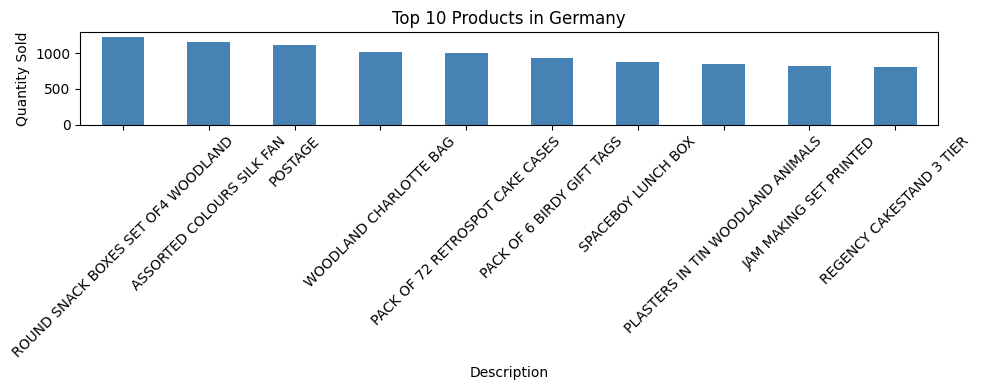


 MONTH-WISE recommendations for: 'November 2011'
-------------------------------------------------------
  1. RABBIT NIGHT LIGHT  (12,393 units sold)
  2. POPCORN HOLDER  (8,458 units sold)
  3. PAPER CHAIN KIT 50'S CHRISTMAS  (5,919 units sold)
  4. JUMBO BAG RED RETROSPOT  (5,678 units sold)
  5. ASSORTED COLOUR BIRD ORNAMENT  (5,190 units sold)
  6. WOODEN STAR CHRISTMAS SCANDINAVIAN  (4,981 units sold)
  7. WHITE HANGING HEART T-LIGHT HOLDER  (4,861 units sold)
  8. WOODEN HEART CHRISTMAS SCANDINAVIAN  (4,582 units sold)
  9. WORLD WAR 2 GLIDERS ASSTD DESIGNS  (4,500 units sold)
  10. DISCO BALL CHRISTMAS DECORATION  (4,391 units sold)


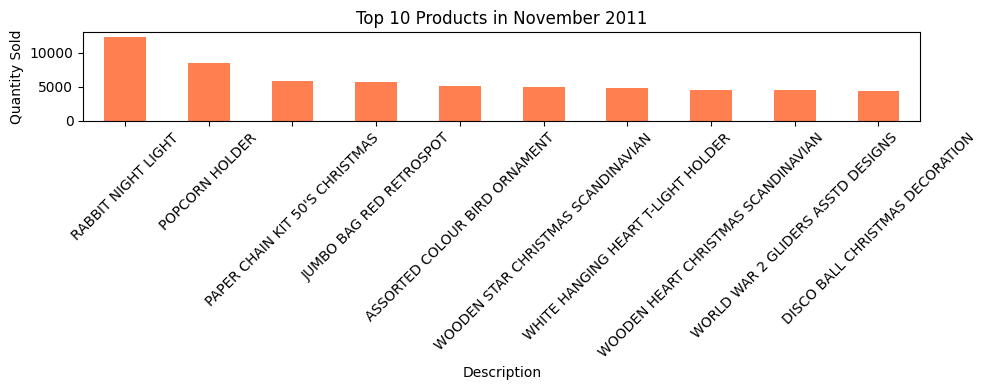

In [51]:
# Predict — Full Recommendation Pipeline 
def predict_recommendations(product_name=None, country=None, month=None):
    """
    Master recommendation function.
    Combines all 3 types based on what inputs are provided.
 
    Usage:
      predict_recommendations(product_name="WHITE HANGING HEART T-LIGHT HOLDER")
      predict_recommendations(country="Germany")
      predict_recommendations(month="2011-11")
      predict_recommendations(product_name="...", country="Germany")
    """
    print("\n" + "=" * 55)
    print("  RECOMMENDATION ENGINE")
    print("=" * 55)
 
    if product_name:
        recommend_global(product_name)
 
    if country:
        recommend_by_country(country)
 
    if month:
        recommend_by_month(month)
 
    if not any([product_name, country, month]):
        print("Please provide at least one of: product_name, country, month")
 
 
# Full pipeline demo 
predict_recommendations(
    product_name="WHITE HANGING HEART T-LIGHT HOLDER",
    country="Germany",
    month="2011-11"
)

# Conclusion
 Dataset    : UCI Online Retail — 541,909 raw transactions
After cleaning: ~397,000 valid rows across 37 countries
Date range : December 2010 to December 2011
 
Key Findings:
- Top product by quantity : PAPER CRAFT, LITTLE BIRDIE (80,995 units)
- Top product by revenue  : PAPER CRAFT, LITTLE BIRDIE (£168,469)
- Top country             : United Kingdom (~85% of total revenue)
- Peak sales month        : November 2011
 
Recommendation System — 3 types built as per project brief:
1. Global     — products frequently bought together (co-occurrence)
2. Country-wise — top products per country by quantity sold
3. Month-wise   — top products per month by quantity sold
 
This system can help e-commerce platforms:
- Personalise product suggestions per region
- Plan inventory ahead of peak months (Nov-Dec)
- Bundle frequently co-purchased products for promotions